In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

PyTorch: 2.10.0+cu128
Device: cuda


In [2]:
import torch
!pip install transformers datasets -q

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
# Using torch.optim.AdamW as the transformers.optimization.AdamW is no longer available
from torch.optim import AdamW
from datasets import load_dataset

Self-Attention: Query, key, value

In [3]:
"""
Each word has three representations:

  QUERY (Q): "What am I looking for?"
  KEY (K):   "What do I contain?"
  VALUE (V): "What do I return if matched?"

  Analogy: Library search
  • Query = your search term
  • Key = book titles
  • Value = book contents

For each word:
  Q = W_q × word_embedding
  K = W_k × word_embedding
  V = W_v × word_embedding

Attention score:
  score(i,j) = Q_i · K_j  (dot product)

"""

'\nEach word has three representations:\n\n  QUERY (Q): "What am I looking for?"\n  KEY (K):   "What do I contain?"\n  VALUE (V): "What do I return if matched?"\n\n  Analogy: Library search\n  • Query = your search term\n  • Key = book titles\n  • Value = book contents\n\nFor each word:\n  Q = W_q × word_embedding\n  K = W_k × word_embedding\n  V = W_v × word_embedding\n\nAttention score:\n  score(i,j) = Q_i · K_j  (dot product)\n\n'

In [4]:
#Implementing a simple self-attention
def self_attention(Q, K, V):
  """
  Q, K, V: (batch, seq_len, embed_dim)
  """
  d_k = Q.size(-1)

  #Attention scores
  scores = torch.matmul(Q, K.transpose(-2, -1))  # (batch, seq_len, seq_len)

  # Scale by sqrt(d_k) for obtaining stable gradients
  scores = scores / np.sqrt(d_k)

  #softmax to get attention weights
  attention_weights = torch.softmax(scores, dim=-1)

  # The weighted sum of values
  output = torch.matmul(attention_weights, V)   # (batch, seq_len, d_k)

  return output, attention_weights

# Demo
batch_size, seq_len, d_k = 1, 4, 8
Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)

output, weights = self_attention(Q, K, V)

print(f"Q, K, V shape: {Q.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {weights.shape}")
print(f"\nAttention weights (each row sums to 1):")
print(weights[0].numpy().round(3))

Q, K, V shape: torch.Size([1, 4, 8])
Output shape: torch.Size([1, 4, 8])
Attention weights shape: torch.Size([1, 4, 4])

Attention weights (each row sums to 1):
[[0.194 0.41  0.324 0.071]
 [0.041 0.656 0.086 0.217]
 [0.104 0.206 0.182 0.508]
 [0.193 0.18  0.195 0.432]]


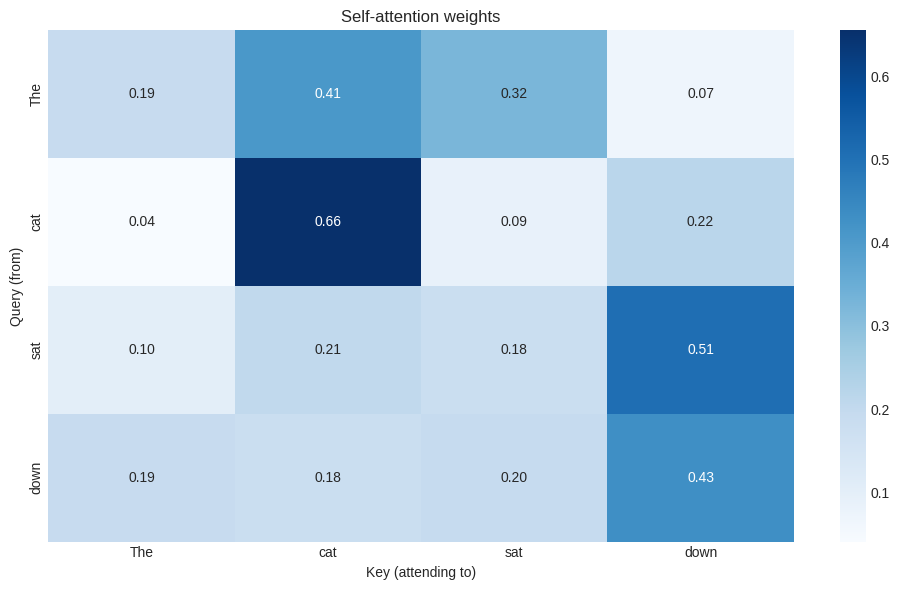

In [5]:
words = ['The', 'cat', 'sat', 'down']

plt.figure(figsize=(10, 6))
sns.heatmap(weights[0].numpy(), annot=True, fmt='.2f', cmap='Blues', xticklabels=words, yticklabels=words)
plt.xlabel('Key (attending to)')
plt.ylabel('Query (from)')
plt.title('Self-attention weights')
plt.tight_layout()
plt.show()

In [6]:
"""
SCALED DOT-PRODUCT ATTENTION

Formula:
                    Q × K^T
  Attention(Q,K,V) = softmax(─────────) × V
                      √d_k

Why scale by √d_k?
  • Large dot products → extreme softmax (all 0s and 1s)
  • Extreme softmax → vanishing gradients
  • Scaling keeps values in good range

Example:
  d_k = 64
  √d_k = 8

  Without scaling: scores might be [-50, 100, 20, -30]
  After softmax: [0, 1, 0, 0] (too extreme!)

  With scaling: [-6.25, 12.5, 2.5, -3.75]
  After softmax: [0.001, 0.99, 0.005, 0.004] (better gradients)

"""

'\nSCALED DOT-PRODUCT ATTENTION\n\nFormula:\n                    Q × K^T\n  Attention(Q,K,V) = softmax(─────────) × V\n                      √d_k\n\nWhy scale by √d_k?\n  • Large dot products → extreme softmax (all 0s and 1s)\n  • Extreme softmax → vanishing gradients\n  • Scaling keeps values in good range\n\nExample:\n  d_k = 64\n  √d_k = 8\n\n  Without scaling: scores might be [-50, 100, 20, -30]\n  After softmax: [0, 1, 0, 0] (too extreme!)\n\n  With scaling: [-6.25, 12.5, 2.5, -3.75]\n  After softmax: [0.001, 0.99, 0.005, 0.004] (better gradients)\n\n'

In [7]:
"""
MULTI-HEAD ATTENTION

Idea: Run multiple attention operations in parallel.

Why?
  • Different heads learn different patterns
  • Head 1: Syntactic relationships (subject-verb)
  • Head 2: Semantic relationships (synonyms)
  • Head 3: Positional patterns

                    ┌─── Head 1 ───┐
                    │              │
  Input ───────────├─── Head 2 ───├───► Concat ───► Linear ───► Output
                    │              │
                    └─── Head 3 ───┘

Each head:
  • Has its own W_q, W_k, W_v
  • Operates on d_k = d_model / num_heads

BERT uses:
  • 12 attention heads
  • d_model = 768
  • d_k = 768 / 12 = 64 per head

  """

'\nMULTI-HEAD ATTENTION\n\nIdea: Run multiple attention operations in parallel.\n\nWhy?\n  • Different heads learn different patterns\n  • Head 1: Syntactic relationships (subject-verb)\n  • Head 2: Semantic relationships (synonyms)\n  • Head 3: Positional patterns\n\n                    ┌─── Head 1 ───┐\n                    │              │\n  Input ───────────├─── Head 2 ───├───► Concat ───► Linear ───► Output\n                    │              │\n                    └─── Head 3 ───┘\n\nEach head:\n  • Has its own W_q, W_k, W_v\n  • Operates on d_k = d_model / num_heads\n\nBERT uses:\n  • 12 attention heads\n  • d_model = 768\n  • d_k = 768 / 12 = 64 per head\n\n  '

In [8]:
#Multi-head attention module
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, num_heads):
    super().__init__()
    self.num_heads =  num_heads
    self.d_model = d_model
    self.d_k = d_model // num_heads

    self.w_q = nn.Linear(d_model, d_model)
    self.w_k = nn.Linear(d_model, d_model)
    self.w_v = nn.Linear(d_model, d_model)
    self.w_o = nn.Linear(d_model, d_model)

  def forward(self, x):
    batch_size, seq_len, _ = x.size()

    #Linear projections
    Q = self.w_q(x)
    K = self.w_k(x)
    V = self.w_v(x)

    # Split into heads: (batch, num_heads, seq_len, d_model)
    Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
    K = K.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
    V = V.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

    # Attention
    scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.d_k)
    attention = torch.softmax(scores, dim=1)
    context = torch.matmul(attention, V)

    # Concat heads
    context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

    # Final linear
    output = self.w_o(context)

    return output, attention

# A demo
mha = MultiHeadAttention(d_model=512, num_heads=8)
x = torch.randn(1, 10, 512)
output, attention = mha(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Attention shape: {attention.shape}")


Input shape: torch.Size([1, 10, 512])
Output shape: torch.Size([1, 10, 512])
Attention shape: torch.Size([1, 8, 10, 10])


In [9]:
"""
POSITIONAL ENCODING:

Problem: Attention has no notion of order!
  "cat sat mat" = "mat sat cat" (same attention)

Solution: Add position information to embeddings.

Original Transformer uses sinusoidal encoding:
  PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
  PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

Why sin/cos?
  • Unique encoding for each position
  • Can extrapolate to longer sequences
  • Relative positions can be computed

BERT uses learned positional embeddings instead:
  • Just another embedding layer
  • Position 0, 1, 2, ... each get their own learned vector
  • Max sequence length = 512

"""

'\nPOSITIONAL ENCODING:\n\nProblem: Attention has no notion of order!\n  "cat sat mat" = "mat sat cat" (same attention)\n\nSolution: Add position information to embeddings.\n\nOriginal Transformer uses sinusoidal encoding:\n  PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))\n  PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))\n\nWhy sin/cos?\n  • Unique encoding for each position\n  • Can extrapolate to longer sequences\n  • Relative positions can be computed\n\nBERT uses learned positional embeddings instead:\n  • Just another embedding layer\n  • Position 0, 1, 2, ... each get their own learned vector\n  • Max sequence length = 512\n\n'

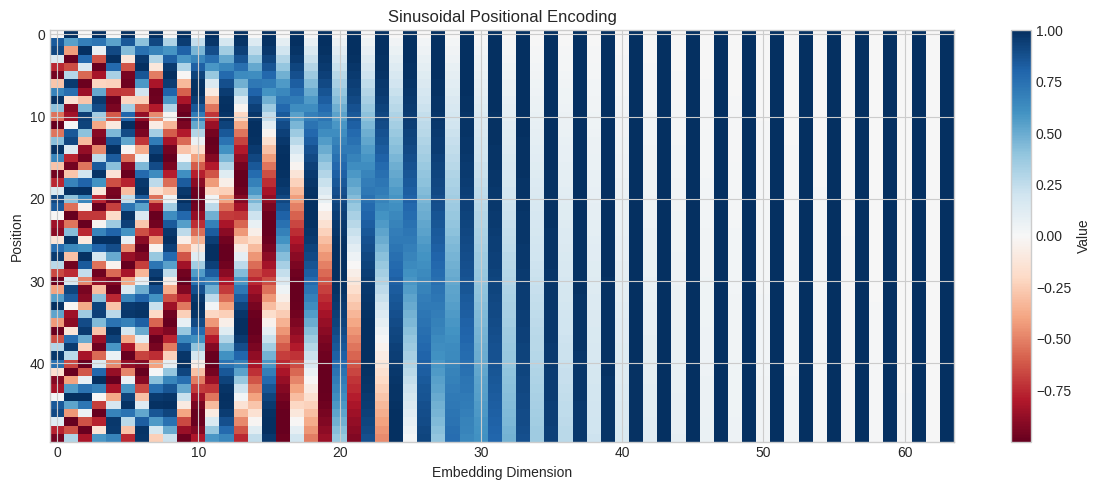

In [10]:
# Visualize sinusoidal positional encoding
def positional_encoding(max_len, d_model):
    pe = np.zeros((max_len, d_model))
    position = np.arange(max_len)[:, np.newaxis]
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)

    return pe

pe = positional_encoding(50, 64)

plt.figure(figsize=(12, 5))
plt.imshow(pe, aspect='auto', cmap='RdBu')
plt.colorbar(label='Value')
plt.xlabel('Embedding Dimension')
plt.ylabel('Position')
plt.title('Sinusoidal Positional Encoding')
plt.tight_layout()
plt.show()

In [11]:
#loading the AG News dataset
dataset = load_dataset('ag_news')

train_data = dataset['train']
test_data = dataset['test']

class_names = ['World', 'Sports', 'Business', 'Sci/Tech']

print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")
print(f'Classes: {len(class_names)}')

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train size: 120000
Test size: 7600
Classes: 4


In [12]:
#Using a subset for faster training
TRAIN_SIZE = 20000
TEST_SIZE = 4000

train_texts = [train_data[i]['text'] for i in range(TRAIN_SIZE)]
train_labels = [train_data[i]['label'] for i in range(TRAIN_SIZE)]

test_texts = [test_data[i]['text'] for i in range(TEST_SIZE)]
test_labels = [test_data[i]['label'] for i in range(TEST_SIZE)]

print(f"Train size: {len(train_texts)}")
print(f"Test size: {len(test_texts)}")

Train size: 20000
Test size: 4000


BERT Tokenizer

In [13]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"Special Token: ")
print(f"   [CLS]: {tokenizer.cls_token} | {tokenizer.cls_token_id}")
print(f"   [SEP]: {tokenizer.sep_token} | {tokenizer.sep_token_id}")
print(f"   [PAD]: {tokenizer.sep_token} | {tokenizer.sep_token_id}")
print(f"   [UNK]: {tokenizer.sep_token} | {tokenizer.sep_token_id}")
print(f"   [MASK]: {tokenizer.sep_token} | {tokenizer.sep_token_id}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocabulary size: 30522
Special Token: 
   [CLS]: [CLS] | 101
   [SEP]: [SEP] | 102
   [PAD]: [SEP] | 102
   [UNK]: [SEP] | 102
   [MASK]: [SEP] | 102


In [14]:
# A tokenization example
sample_text = "Apple releases new iphone with amazing AI features!"

encoded = tokenizer(
    sample_text,
    padding='max_length',
    truncation=True,
    max_length=32,
    return_tensors='pt'
)

print(f"Original: {sample_text}")
print(f"\nTokens: {tokenizer.tokenize(sample_text)}")
print(f"\nInput IDs: {encoded['input_ids'][0][:15].tolist()}...")
print(f"Attention mask: {encoded['attention_mask'][0][:15].tolist()}...")

# DEcode back
print(f"\n Decoded: {tokenizer.decode(encoded['input_ids'][0])}")

Original: Apple releases new iphone with amazing AI features!

Tokens: ['apple', 'releases', 'new', 'iphone', 'with', 'amazing', 'ai', 'features', '!']

Input IDs: [101, 6207, 7085, 2047, 18059, 2007, 6429, 9932, 2838, 999, 102, 0, 0, 0, 0]...
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]...

 Decoded: [CLS] apple releases new iphone with amazing ai features! [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


Create Dataset & DataLoaders

In [15]:
class AGNewsDataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_len=120):
    self.texts = texts
    self.labels = labels
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, idx):
    text = self.texts[idx]
    label = self.labels[idx]

    encoding = self.tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=self.max_len,
        return_tensors='pt'
    )

    return {
        'input_ids': encoding['input_ids'].squeeze(0),
        'attention_mask': encoding['attention_mask'].squeeze(0),
        'label': torch.tensor(label, dtype=torch.long)
    }

print("Dataloader created")

Dataloader created


In [16]:
MAX_LEN = 128
BATCH_SIZE = 16

train_dataset = AGNewsDataset(train_texts, train_labels, tokenizer, MAX_LEN)
test_dataset = AGNewsDataset(test_texts, test_labels, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 1250
Test batches: 250


Laoding pre-trained BERT

In [17]:
# Load BERT for sequence classification
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=4  # 4 classes
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: BERT-base-uncased")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: BERT-base-uncased
Total parameters: 109,485,316
Trainable parameters: 109,485,316


In [18]:
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

#scheduler
EPOCHS = 3
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)


In [19]:
def train_epoch(model, loader, optimizer, scheduler):
  model.train()
  total_loss = 0
  correct = 0
  total = 0

  for batch in loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['label'].to(device)

    optimizer.zero_grad()

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    loss = outputs.loss
    logits = outputs.logits

    loss.backward()
    optimizer.step()
    scheduler.step()

    total_loss += loss.item()
    _, predicted = torch.max(logits, 1)
    correct += (predicted == labels).sum().item()
    total += labels.size(0)

  return total_loss / len(loader), correct / total

def evaluate(model, loader):
  model.eval()
  total_loss = 0
  correct = 0
  total  =  0
  with torch.no_grad():
    for batch in loader:
      input_ids = batch['input_ids'].to(device)
      attention_mask = batch['attention_mask'].to(device)
      labels = batch['label'].to(device)

      outputs = model(
          input_ids=input_ids,
          attention_mask=attention_mask,
          labels=labels
      )

      total_loss += outputs.loss.item()
      _, predicted = torch.max(outputs.logits, 1)
      correct += (predicted == labels).sum().item()
      total += labels.size(0)

  return total_loss / len(loader), correct / total

Train BERT

In [20]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(EPOCHS):
  train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler)
  val_loss, val_acc = evaluate(model, test_loader)

  history['train_loss'].append(train_loss)
  history['train_loss'].append(train_acc)
  history['val_loss'].append(val_loss)
  history['val_acc'].append(val_acc)

  if val_acc > best_val_acc:
    best_val_acc = val_acc
    torch.save(model.state_dict(), 'best_bert_model.pt')
    print(f"Saved best model with val_acc: {val_acc}")
  else:
    marker = ''

  print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2%} | ")

print(f"\n Best Validation acc: {best_val_acc:.2%}")

Saved best model with val_acc: 0.921
Epoch 1/3 | Train Loss: 0.3028 | Train Acc: 89.84% | Val Loss: 0.2311 | Val Acc: 92.10% | 
Saved best model with val_acc: 0.9245
Epoch 2/3 | Train Loss: 0.1357 | Train Acc: 95.56% | Val Loss: 0.2412 | Val Acc: 92.45% | 
Saved best model with val_acc: 0.92725
Epoch 3/3 | Train Loss: 0.0780 | Train Acc: 97.56% | Val Loss: 0.2523 | Val Acc: 92.73% | 

 Best Validation acc: 92.73%


In [21]:
model.load_state_dict(torch.load('best_bert_model.pt'))
print("Model loaded")

Model loaded


In [23]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
  for batch in test_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['label']

    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    _, predicted = torch.max(outputs.logits, 1)

    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(labels.numpy())

  all_preds = np.array(all_preds)
  all_labels = np.array(all_labels)

In [24]:
print("Classification Report: ")
print(classification_report(all_labels, all_preds, target_names=class_names))

Classification Report: 
              precision    recall  f1-score   support

       World       0.94      0.94      0.94      1035
      Sports       0.98      0.99      0.98      1014
    Business       0.90      0.85      0.88       948
    Sci/Tech       0.88      0.93      0.90      1003

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000



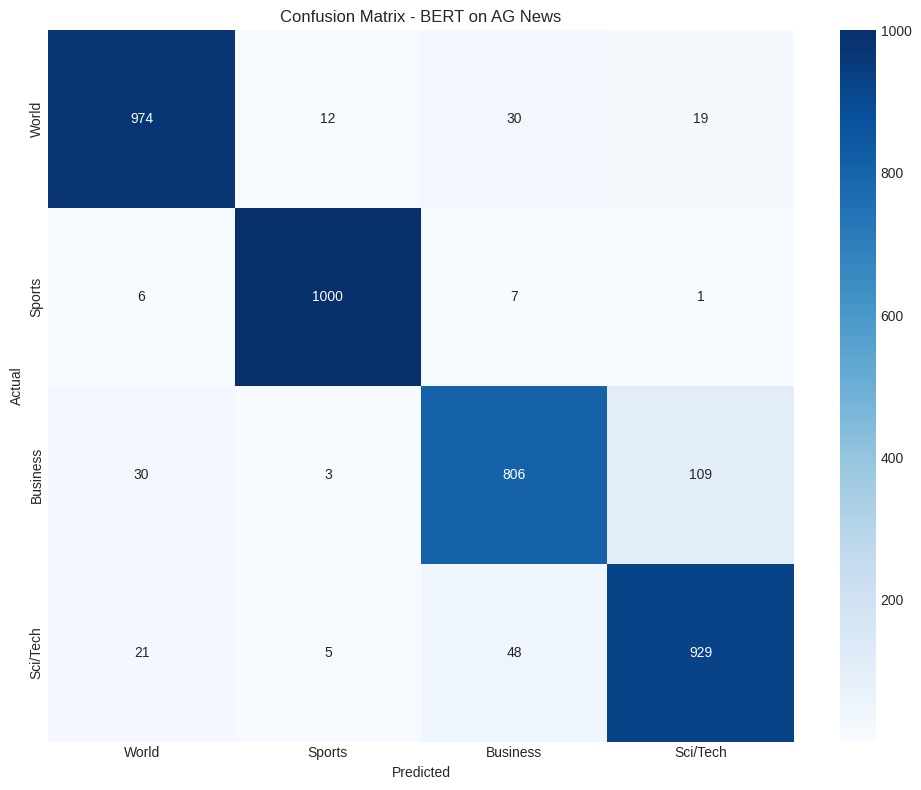

In [25]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - BERT on AG News')
plt.tight_layout()
plt.show()

Testing on a custom set

In [26]:
# Prediction function
def predict_text(text, model, tokenizer, class_names):
    model.eval()

    encoding = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[0]
        pred_idx = torch.argmax(probs).item()

    return class_names[pred_idx], probs.cpu().numpy()

print("Prediction function ready")

Prediction function ready


In [28]:
# Test headlines
test_headlines = [
    "Apple announces new iPhone with revolutionary AI features",
    "Lakers defeat Celtics in thrilling overtime victory",
    "Stock market reaches all-time high amid economic recovery",
    "UN Security Council meets to discuss Middle East crisis",
    "Scientists discover New species in Amazon rainforest",
    "Tesla unveils new electric car with 500 mile range",
]

print("BERT Predictions:")


for headline in test_headlines:
    pred_class, probs = predict_text(headline, model, tokenizer, class_names)

    print(f"\n\"{headline}\"")
    print(f"  → {pred_class} ({max(probs):.1%})")

BERT Predictions:

"Apple announces new iPhone with revolutionary AI features"
  → Sci/Tech (99.0%)

"Lakers defeat Celtics in thrilling overtime victory"
  → Sports (86.4%)

"Stock market reaches all-time high amid economic recovery"
  → Business (99.2%)

"UN Security Council meets to discuss Middle East crisis"
  → World (99.7%)

"Scientists discover New species in Amazon rainforest"
  → Sci/Tech (56.6%)

"Tesla unveils new electric car with 500 mile range"
  → Sci/Tech (50.7%)


Visualize Attention

In [30]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=4,
    attn_implementation='eager'
)

model = model.to(device)

print("BERT model reloaded with eager attention implementation.")

# Reload the best weights if available
try:
    model.load_state_dict(torch.load('best_bert_model.pt'))
    print("Previously trained best weights loaded.")
except FileNotFoundError:
    print("No 'best_bert_model.pt' found. Using newly initialized model.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model reloaded with eager attention implementation.
Previously trained best weights loaded.


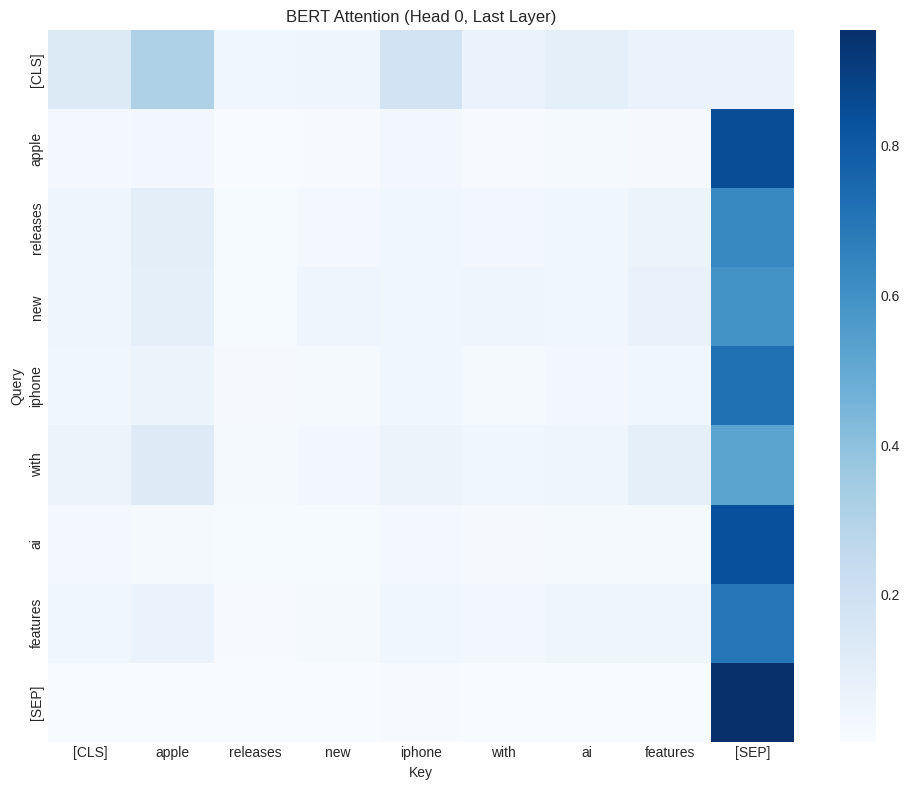

In [32]:
# Get attention weights
def get_attention(text, model, tokenizer):
    model.eval()

    encoding = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=32,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True
        )

    # Get last layer attention
    attention = outputs.attentions[-1]  # (batch, heads, seq, seq)
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    return attention[0].cpu().numpy(), tokens

# Visualize
sample = "Apple releases new iPhone with AI features"
attention, tokens = get_attention(sample, model, tokenizer)

# Plot attention for head 0
fig, ax = plt.subplots(figsize=(10, 8))

# Trim to actual tokens (not padding)
n_tokens = sum(1 for t in tokens if t != '[PAD]')
attn_trimmed = attention[0, :n_tokens, :n_tokens]
tokens_trimmed = tokens[:n_tokens]

sns.heatmap(attn_trimmed, xticklabels=tokens_trimmed, yticklabels=tokens_trimmed,
            cmap='Blues', ax=ax)
ax.set_title('BERT Attention (Head 0, Last Layer)')
ax.set_xlabel('Key')
ax.set_ylabel('Query')
plt.tight_layout()
plt.show()

In [33]:
import os

from google.colab import drive
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-51-transformers'
os.makedirs(save_path, exist_ok=True)

# Save model and tokenizer
model.save_pretrained(f'{save_path}/bert_agnews')
tokenizer.save_pretrained(f'{save_path}/bert_agnews')

print(f"\nSaved to: {save_path}/bert_agnews")
print("\nTo load later:")
print("  model = BertForSequenceClassification.from_pretrained('bert_agnews')")
print("  tokenizer = BertTokenizer.from_pretrained('bert_agnews')")

Mounted at /content/drive


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved to: /content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-51-transformers/bert_agnews

To load later:
  model = BertForSequenceClassification.from_pretrained('bert_agnews')
  tokenizer = BertTokenizer.from_pretrained('bert_agnews')
